# Tutorial 2: Evaluating LLMs on MMLU

Welcome to the second tutorial in our AI Safety Evaluations course.

Benchmark evaluation is a core skill in applied ML, but the statistical side is often
treated as an afterthought — a single accuracy number gets reported, and model differences
are treated as real without checking whether they could arise from chance alone.
In this tutorial you will get hands-on experience running evaluations with the inspect_ai
library and applying basic statistical methods to interpret the results rigorously.

**What you'll learn:**

- Load and prepare a benchmark dataset
- Compute confidence intervals for accuracy
- Compare models statistically
- Perform power analysis to plan evaluation size

**By the end:** **You'll have a statistically rigorous evaluation pipeline that can tell you not just how accurate a model is, but whether observed differences between models are real.**

## 1. Setup

In [1]:
from string import ascii_uppercase
from typing import Tuple, List

import dotenv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from inspect_ai import Task, task, eval
from inspect_ai.dataset import Sample, hf_dataset, FieldSpec
from inspect_ai.log import EvalLog
from inspect_ai.scorer import choice
from inspect_ai.solver import multiple_choice
from scipy import stats

dotenv.load_dotenv()
import os

os.environ["OPENAI_API_KEY"] = os.environ["DEEPSEEK_API_KEY"]
os.environ["OPENAI_BASE_URL"] = "https://api.deepseek.com/v1"


In [2]:
# Configure models -- replace with what is available in your environment.
# Examples: 'ollama/llama3.2', 'openai/gpt-4o-mini', 'anthropic/claude-haiku-4-5'

# MODEL_A = "ollama/llama3"  # weaker / baseline model
MODEL_A = "ollama/gemma2:2b"  # weaker / baseline model
# MODEL_B = "openai/deepseek-chat"  # stronger / comparison model
MODEL_B = "ollama/llama3"  # stronger / comparison model

## 2. Loading MMLU

`hf_dataset` is inspect_ai's loader for Hugging Face datasets. It downloads the data
and wraps each record in a `Sample` -- the standard container that flows through every
inspect_ai pipeline. A `Sample` carries the model input, the expected target, optional
answer choices, and arbitrary metadata you want to keep around.

MMLU stores the correct answer as an integer (0 = A, 1 = B, 2 = C, 3 = D).
The quickest way to load a dataset is with `FieldSpec`, which maps column names to
`Sample` fields. Let's try it first and see what we get.

In [3]:
dataset_raw = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=FieldSpec(
        input="question",
        target="answer",  # raw MMLU answer is an integer index 0-3
        metadata=["choices", "subject"]
    ),
    cached=True
)

sample = dataset_raw[0]
print("input   :", sample.input[:80], "...")
print("target  :", sample.target, "  <- integer index, not a letter!")
print("choices :", sample.metadata.get("choices"))

input   : Find the degree for the given field extension Q(sqrt(2), sqrt(3), sqrt(18)) over ...
target  : 1   <- integer index, not a letter!
choices : ['0', '4', '2', '6']


The `target` came out as an integer -- but inspect_ai's `multiple_choice()` solver
and `choice()` scorer expect it to be a letter (`"A"`, `"B"`, `"C"`, or `"D"`).
When the automatic mapping isn't enough, inspect_ai lets you pass a
**record-to-sample function** that receives the full raw record and returns a `Sample`
you construct yourself.

In [4]:
def record_to_sample(record: dict) -> Sample:
    """
    Convert a raw MMLU record to an inspect_ai Sample.

    MMLU stores the correct answer as an integer index (0=A, 1=B, 2=C, 3=D).
    We convert it to the corresponding uppercase letter so it matches the
    format expected by the choice() scorer.
    """
    answer_idx = int(record["answer"])
    return Sample(
        input=record["question"],
        choices=record["choices"],
        target=ascii_uppercase[answer_idx],  # 0->'A', 1->'B', ...
        metadata=dict(subject=record.get("subject"))
    )


dataset = hf_dataset(
    path="cais/mmlu",
    name="all",
    split="test",
    sample_fields=record_to_sample,
    cached=True
)

sample = dataset[0]
print("target  :", sample.target, " <- letter now")
print("choices :", sample.choices)

target  : B  <- letter now
choices : ['0', '4', '2', '6']


## Assignment 1: Create your working subset

All experiments in this notebook will run on a subject subset small enough to evaluate
quickly. `Dataset.filter()` takes a predicate over `Sample` objects; the `metadata`
field gives access to anything set in `record_to_sample` -- here, the MMLU subject tag.

We define `astronomy_subset` as a reference example. Pick any subject or subjects from the [MMLU subject list](https://huggingface.co/datasets/cais/mmlu#task-descriptions) with at least 50 questions so later analyses are statistically meaningful. Create MY_SUBSET and use it in all subsequent exercises.

In [11]:
# Reference subset used in worked examples
astronomy_subset = dataset.filter(
    lambda s: s.metadata.get("subject") == "astronomy"
)
print(f"Astronomy: {len(astronomy_subset)} questions")

MY_SUBSET = dataset.filter(lambda s: s.metadata.get("subject") == "formal_logic")

print(f"My subset: {len(MY_SUBSET)} questions")

Astronomy: 152 questions
My subset: 126 questions


## 3. Running an evaluation

Every inspect_ai evaluation is described by a `Task`, which bundles three things:

- **dataset** -- the questions
- **solver** -- the chain of steps that produces a model response;
  `multiple_choice()` formats the prompt with lettered options and parses the model's choice
- **scorer** -- the function that grades the response;
  `choice()` checks whether the selected letter matches the target

The `@task` decorator registers the function so inspect_ai can discover it by name
from the CLI or pass it directly to `eval()`.

In [12]:
@task
def mmlu_subset(subset):
    """Minimal MMLU task for any subject subset."""
    return Task(
        dataset=subset,
        solver=[multiple_choice()],
        scorer=choice()
    )

Calling `eval()` runs the task and returns a **list of `EvalLog` objects** -- one per
(task, model) pair. Everything you need is in this object; there is no need to read
log files from disk.

The two most useful attributes:
- `log.results.scores` -- list of scorer results, each with a `metrics` dict
  (`"accuracy"`, `"stderr"`, etc.)
- `log.samples` -- list of `EvalSample` objects with per-question inputs, outputs, and scores

In [14]:
logs: List[EvalLog] = eval(
    mmlu_subset(astronomy_subset),
    model=MODEL_A,
    # limit=10  # evaluate only the first 10 questions
)

log = logs[0]  # one task -> one log
print("Status  :", log.status)
print("Model   :", log.eval.model)
print("Accuracy:", log.results.scores[0].metrics["accuracy"].value)

Output()

[04/15/26 18:54:36] ERROR    Exception in callback Task.__step()                                ]8;id=4827531;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827532;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gn                    
                             u/lib/python3.12/asyncio/events.py", line 88, in _run                                 
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x766f7c5ec440> is already entered                                                 

[04/15/26 18:54:40] ERROR    Task was destroyed but it is pending!                              ]8;id=4827539;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827540;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             task: <Task pending name='Task-281'                                                   
                             coro=<_async_in_context.<locals>.run_in_context() running at                          
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/utils.py:60> wait_for=<Task pending name='Task-282'                       
                             coro=<Kernel.shell_main() running at                                                  
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]>                                  
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/zmq/eventloop/zmqstream.py:563]>                                                    

/home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/fractions.py:217: RuntimeWarning:
coroutine 'Kernel.shell_main' was never awaited
  self = super(Fraction, cls).__new__(cls)
RuntimeWarning: Enable tracemalloc to get the object allocation traceback

                    ERROR    Task was destroyed but it is pending!                              ]8;id=4827547;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827548;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             task: <Task pending name='Task-282' coro=<Kernel.shell_main()                         
                             running at                                                                            
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]>                                  

Status  : success
Model   : ollama/gemma2:2b
Accuracy: 0.5855263157894737


## 4. From `EvalLog` to a DataFrame

## Assignment 2: Implement `log_to_df`

The aggregate accuracy in `log.results` is useful for a quick check, but for the
statistical analyses ahead we need a flat table: **one row per (question, epoch)**
with a numeric `score` column.

`log.samples` is a list of `EvalSample` objects. Each one has:
- `.id` -- question identifier
- `.epoch` -- which run this belongs to (relevant when `epochs > 1`)
- `.scores` -- a dict mapping scorer name to `Score`; the `Score.value` for `choice()` is
  `"C"` (correct) or `"I"` (incorrect)
- `.metadata` -- the metadata dict you set in `record_to_sample`

Implement `log_to_df` so that it converts an `EvalLog` into a DataFrame with columns
`id`, `epoch`, `score` (1/0), and `subject`. The smoke test below will verify the shape.

In [16]:
def log_to_df(log: EvalLog) -> pd.DataFrame:
    """
    Convert an EvalLog to a DataFrame with one row per (question, epoch).

    Columns:
        id      – question identifier
        epoch   – epoch index (0 if epochs=1)
        score   – 1 if correct, 0 otherwise
        subject – MMLU subject tag from metadata

    The choice() scorer stores the result as "C" (correct) or "I" (incorrect).
    """
    rows = []
    for sample in log.samples:
        scorer_name = next(iter(sample.scores))
        value = sample.scores[scorer_name].value
        rows.append({
            "id": sample.id,
            "epoch": sample.epoch,
            "score": 1 if value == "C" else 0,
            "subject": (sample.metadata or {}).get("subject"),
        })
    return pd.DataFrame(rows)


# =================================== TESTS ===================================
df_test = log_to_df(log)

assert set(df_test.columns) >= {"id", "epoch", "score", "subject"}
assert df_test["score"].isin([0, 1]).all()
assert len(df_test) == 10

print(df_test.head())
print(f"\nAccuracy: {df_test['score'].mean():.1%}")

   id  epoch  score    subject
0   1      1      1  astronomy
1   2      1      1  astronomy
2   3      1      1  astronomy
3   4      1      0  astronomy
4   5      1      1  astronomy

Accuracy: 58.6%


## 5. Confidence intervals


A single accuracy number carries uncertainty: the eval used a finite set of questions
sampled from a much larger space. The paper (ss2.1, ss3.1) shows how to quantify this
using the CLT standard error.


## Assignment 3: Implement `ci_accuracy_basic` and `ci_accuracy`

**`ci_accuracy_basic(scores, ci)`** -- the simple case where every question is answered
exactly once. `scores` is a plain numpy array of 0s and 1s. Use Eq. 1 from the paper.

**`ci_accuracy(df, ci)`** -- the general case that handles multiple runs per question
(`epochs > 1`). When K runs exist for a question, average their scores first, then
compute the SE across question-level averages. Pooling all K×n individual answers
would undercount variance -- answers to the same question across epochs are correlated.


In [17]:
def ci_accuracy_basic(scores: np.ndarray, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy -- single run per question (K = 1).

    Parameters
    ----------
    scores : 1-D array of per-question binary scores (0 or 1)
    ci     : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    n = len(scores)
    mean = float(np.mean(scores))
    z = stats.norm.ppf((1 + ci) / 2)
    se = np.sqrt(mean * (1 - mean) / n)
    lower = float(np.clip(mean - z * se, 0.0, 1.0))
    upper = float(np.clip(mean + z * se, 0.0, 1.0))
    return lower, mean, upper


def ci_accuracy(df: pd.DataFrame, ci: float = 0.95) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for accuracy, supporting multiple epochs (K >= 1).

    Parameters
    ----------
    df : DataFrame returned by log_to_df, with columns 'id', 'score', 'epoch'
    ci : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_accuracy, upper_bound)
    """
    # Average scores per question across epochs, then apply CLT over question-level means
    per_question = df.groupby("id")["score"].mean().values
    return ci_accuracy_basic(per_question, ci)

In [18]:
# =================================== TESTS ===================================
def _make_df(ids, scores, epochs=None):
    if epochs is None:
        epochs = [0] * len(ids)
    return pd.DataFrame({"id": ids, "score": scores, "epoch": epochs})


# ci_accuracy_basic
l, m, u = ci_accuracy_basic(np.ones(10))

assert l == 1.0 and u == 1.0, "perfect accuracy: CI should collapse to 1"

l, m, u = ci_accuracy_basic(np.zeros(10))

assert l == 0.0 and u == 0.0, "zero accuracy: CI should collapse to 0"

scores3 = np.array([1, 1, 0, 1, 0], dtype=float)
l, m, u = ci_accuracy_basic(scores3)

assert l < 0.6 < u, f"0.6 not in [{l:.3f}, {u:.3f}]"

np.random.seed(42)
s = np.random.binomial(1, 0.75, 200).astype(float)
l95, _, u95 = ci_accuracy_basic(s, 0.95)
l99, _, u99 = ci_accuracy_basic(s, 0.99)

assert (u99 - l99) > (u95 - l95), "99% CI must be wider than 95%"
assert np.isclose(l95, 0.6819421067148456, atol=10e-2)
assert np.isclose(u95, 0.8080578932851544, atol=10e-2)

# ci_accuracy (K=1 should match basic)
df3 = _make_df([1, 2, 3, 4, 5], scores3.tolist())
l_df, _, u_df = ci_accuracy(df3)
l_ar, _, u_ar = ci_accuracy_basic(scores3)

assert np.isclose(l_df, l_ar) and np.isclose(u_df, u_ar), "K=1 must match basic version"

# ci_accuracy (K=3 should give narrower CI on average)
np.random.seed(0)
rows_k1, rows_k3 = [], []
for q in range(30):
    p = np.random.uniform(0.3, 0.9)
    rows_k1.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": 0})
    for e in range(3):
        rows_k3.append({"id": q, "score": int(np.random.binomial(1, p)), "epoch": e})

l1, _, u1 = ci_accuracy(pd.DataFrame(rows_k1))
l3, _, u3 = ci_accuracy(pd.DataFrame(rows_k3))
print(f"K=1 width: {u1 - l1:.3f}")
print(f"K=3 width: {u3 - l3:.3f}  (narrower on average)")
print("\n✓ All tests passed!")

K=1 width: 0.337
K=3 width: 0.355  (narrower on average)

✓ All tests passed!


## 6. Visualising how CIs shrink

Two things make confidence intervals narrower: more questions (larger n) and more
runs per question (larger K). Your task is to visualise those effects.

## Assignment 4.1: Plot CI width vs number of epochs


Output()

[04/15/26 18:56:40] ERROR    Exception in callback Task.__step()                                ]8;id=4827575;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827576;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gn                    
                             u/lib/python3.12/asyncio/events.py", line 88, in _run                                 
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x766f7c5ec440> is already entered                                                 

[04/15/26 18:56:42] ERROR    Task was destroyed but it is pending!                              ]8;id=4827583;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827584;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             task: <Task pending name='Task-1874'                                                  
                             coro=<_async_in_context.<locals>.run_in_context() running at                          
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/utils.py:60> wait_for=<Task pending name='Task-1875'                      
                             coro=<Kernel.shell_main() running at                                                  
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]>                                  
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/zmq/eventloop/zmqstream.py:563]>                                                    

/home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-packages/inspect_ai/log/_recorders/buffer/database.py:34
4: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  conn.execute("PRAGMA synchronous=OFF")
RuntimeWarning: Enable tracemalloc to get the object allocation traceback

                    ERROR    Task was destroyed but it is pending!                              ]8;id=4827591;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827592;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             task: <Task pending name='Task-1875' coro=<Kernel.shell_main()                        
                             running at                                                                            
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]>                                  

...

[04/15/26 20:36:31] ERROR    Task was destroyed but it is pending!                              ]8;id=4827693;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827694;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             task: <Task pending name='Task-25376'                                                 
                             coro=<_async_in_context.<locals>.run_in_context() done, defined at                    
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/utils.py:57> wait_for=<Task pending name='Task-25377'                     
                             coro=<Kernel.shell_main() running at                                                  
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]>                                  
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/zmq/eventloop/zmqstream.py:563]>                                                    

/home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-packages/httpx/_urls.py:77: RuntimeWarning: coroutine 
'Kernel.shell_main' was never awaited
  def __init__(self, url: URL | str = "", **kwargs: typing.Any) -> None:
RuntimeWarning: Enable tracemalloc to get the object allocation traceback

                    ERROR    Task was destroyed but it is pending!                              ]8;id=4827701;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827702;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             task: <Task pending name='Task-25377' coro=<Kernel.shell_main()                       
                             running at                                                                            
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]>                                  

Output()

[04/15/26 21:10:17] ERROR    Exception in callback Task.__step()                                ]8;id=4827713;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827714;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gn                    
                             u/lib/python3.12/asyncio/events.py", line 88, in _run                                 
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x766f7c5ec440> is already entered                                                 

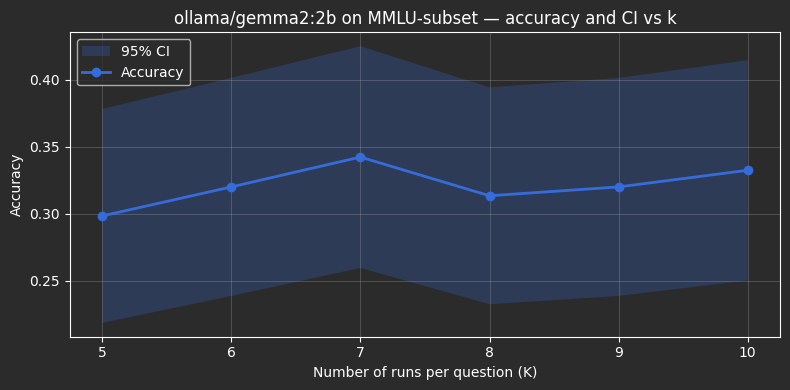

In [19]:
k_values = [5, 6, 7, 8, 9, 10]
accuracies = []
ci_lowers = []
ci_uppers = []

for k in k_values:
    k_logs = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=k)
    k_df = log_to_df(k_logs[0])
    lower, mean, upper = ci_accuracy(k_df)
    accuracies.append(mean)
    ci_lowers.append(lower)
    ci_uppers.append(upper)

plt.figure(figsize=(8, 4))
plt.fill_between(k_values, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(k_values, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of runs per question (K)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs k")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. Look at how fast the band narrows.
   At what point does running another epoch stop being worth it?
2. Does more K change your estimate of the model's accuracy, or just your confidence in it?
3. What does this tell you about how to allocate your evaluation budget?

**Your answer:**: После  K≈6–7 дополнительные прогоны дают убывающую отдачу: доверительный интервал почти не сужается, а оценка accuracy остаётся примерно той же. Значит, увеличение  K в основном влияет на уверенность в оценке, а не на саму оценку качества. Поэтому бюджет лучше тратить на расширение набора вопросов или экспериментов, а не на увеличение числа повторов сверх умеренного уровня

## Assignment 4.2: Compute and plot CI width vs n

For each sample size n in `range(10, len(question_ids)+1, 10)`, slice both DataFrames
to the first n question IDs, compute `ci_accuracy`, and record the CI width.
Then plot width vs n.

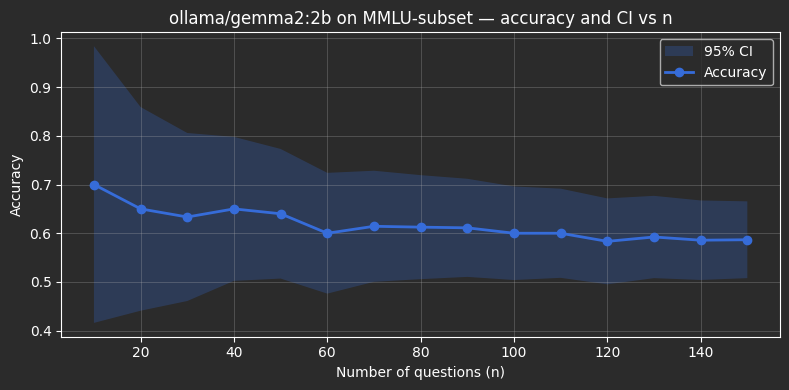

In [20]:
question_ids = df_test["id"].unique()
dataset_sizes = range(10, len(question_ids) + 1, 10)
accuracies = []
ci_lowers = []
ci_uppers = []

for n in dataset_sizes:
    ids_subset = question_ids[:n]
    df_slice = df_test[df_test["id"].isin(ids_subset)]
    lower, mean, upper = ci_accuracy(df_slice)
    accuracies.append(mean)
    ci_lowers.append(lower)
    ci_uppers.append(upper)

plt.figure(figsize=(8, 4))
plt.fill_between(dataset_sizes, ci_lowers, ci_uppers, alpha=0.25, label="95% CI")
plt.plot(dataset_sizes, accuracies, "o-", lw=2, label="Accuracy")
plt.xlabel("Number of questions (n)")
plt.ylabel("Accuracy")
plt.title(f"{MODEL_A} on MMLU-subset — accuracy and CI vs n")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
1. At what n does the accuracy line start to feel stable?
2. Compare that number to the size of `MY_SUBSET` — are you in the reliable region?
3. Compare this curve to the one in 4.1. What is the difference in what K and n actually buy you?

**Your answer:**
1. The accuracy line starts to feel stable at around n ≈ 60–80, because beyond this range the average accuracy changes only slightly and no longer exhibits large fluctuations.
2. Comparing this to MY_SUBSET in the notebook, where 50 questions are used, this size provides a reasonable estimate, but it is closer to the lower bound of the reliable region rather than the fully stable part of the curve.
3. Compared to the curve in 4.1, the difference is that increasing K mainly improves confidence in the estimate for the same set of questions, while increasing n introduces new questions and therefore genuinely improves the reliability and representativeness of the model evaluation.


## 7. Comparing two models

Reporting two accuracy numbers side by side doesn't tell you whether the gap is real
or just noise. The paper (§4.2) describes a **paired test**: because both models answer
the same questions, you can compute per-question score differences and test whether
their mean differs significantly from zero. This removes question-difficulty variance
and yields a lower standard error than treating the two runs as independent samples.


## Assignment 5: Compare two models

`run_and_get_scores` and `compare_models_paired` are provided. Complete
`significance_by_paired_ttest` and use it to compare the two models on `MY_SUBSET`.

Implement `significance_by_paired_ttest` and compare MODEL_A and MODEL_B.

In [21]:
def run_and_get_scores(model_name: str, dataset, epochs: int = 1) -> np.ndarray:
    """Run eval and return mean-per-question scores, sorted by question id."""
    print(f"  Running {model_name} ...")
    run_logs = eval(mmlu_subset(dataset), model=model_name, epochs=epochs)
    df = log_to_df(run_logs[0])
    return df.groupby("id")["score"].mean().sort_index().values


def significance_by_paired_ttest(
        scores1: np.ndarray,
        scores2: np.ndarray,
        alpha: float = 0.05,
        two_tailed: bool = True,
) -> Tuple[float, float, bool]:
    """
    Paired t-test between two sets of per-question scores.

    Returns (p_value, mean_difference scores1 - scores2, is_significant).
    """
    assert len(scores1) == len(scores2), "arrays must cover the same questions"

    alternative = "two-sided" if two_tailed else "greater"

    _, p_value = stats.ttest_rel(scores1, scores2, alternative=alternative)
    mean_diff = float(np.mean(scores1 - scores2))

    return p_value, mean_diff, bool(p_value < alpha)


def compare_models_paired(
        model_a: str,
        model_b: str,
        dataset,
        alpha: float = 0.05,
        two_tailed: bool = True,
        epochs_a: int = 1,
        epochs_b: int = 1,
) -> Tuple[float, float, bool]:
    """
    Evaluate both models on the same dataset and run a paired t-test.

    Returns (p_value, mean_difference A - B, is_significant).
    """
    scores_a = run_and_get_scores(model_a, dataset, epochs=epochs_a)
    scores_b = run_and_get_scores(model_b, dataset, epochs=epochs_b)
    return significance_by_paired_ttest(scores_a, scores_b, alpha, two_tailed)

In [22]:
# =================================== TESTS ===================================
p, d, sig = significance_by_paired_ttest(np.array([1, 2, 3]), np.array([1, 2, 3]))

assert np.isclose(d, 0.0) and not sig

p, d, sig = significance_by_paired_ttest(
    np.array([1, 1, 1, 1, 1]), np.array([0, 0, 0, 0, 0]), two_tailed=False
)

assert sig and d > 0

print("All tests passed!")

All tests passed!


/home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:430: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  return hypotest_fun_in(*args, **kwds)


In [23]:
print(f"Comparing {MODEL_A} vs {MODEL_B} on MY_SUBSET ({len(MY_SUBSET)} questions)...")

p_value, mean_diff, is_significant = compare_models_paired(
    model_a=MODEL_A,
    model_b=MODEL_B,
    dataset=MY_SUBSET,
)

print(f"\nResults:")
print(f"  p-value:         {p_value:.4f}")
print(f"  mean difference: {mean_diff:+.3f}  ({MODEL_A} − {MODEL_B})")
print(f"  significant:     {is_significant}")

if is_significant:
    winner = MODEL_A if mean_diff > 0 else MODEL_B
    print(f"\n→ {winner} is significantly better at α=0.05")
else:
    print(f"\n→ No significant difference detected at α=0.05")

Output()

[04/15/26 22:17:53] ERROR    Exception in callback Task.__step()                                ]8;id=4827739;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827740;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gn                    
                             u/lib/python3.12/asyncio/events.py", line 88, in _run                                 
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x766f7c5ec440> is already entered                                                 

Comparing ollama/gemma2:2b vs ollama/llama3 on MY_SUBSET (126 questions)...
  Running ollama/gemma2:2b ...


Output()

  Running ollama/llama3 ...


[04/15/26 22:21:50] ERROR    Exception in callback Task.__step()                                ]8;id=4827751;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827752;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gn                    
                             u/lib/python3.12/asyncio/events.py", line 88, in _run                                 
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x766f7c5ec440> is already entered                                                 

[04/15/26 22:29:12] ERROR    Task was destroyed but it is pending!                              ]8;id=4827773;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827774;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             task: <Task pending name='Task-41173' coro=<Kernel.shell_main()                       
                             running at                                                                            
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]>                                  

<frozen abc>:117: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
RuntimeWarning: Enable tracemalloc to get the object allocation traceback

                    ERROR    Task was destroyed but it is pending!                              ]8;id=4827781;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827782;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             task: <Task pending name='Task-41172'                                                 
                             coro=<_async_in_context.<locals>.run_in_context() running at                          
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/utils.py:60> wait_for=<Task pending name='Task-41173'                     
                             coro=<Kernel.shell_main() running at                                                  
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]>                                  
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/zmq/eventloop/zmqstream.py:563]>                                                    


Results:
  p-value:         0.0009
  mean difference: -0.190  (ollama/gemma2:2b − ollama/llama3)
  significant:     True

→ ollama/llama3 is significantly better at α=0.05


## 8. Interval estimation of the accuracy difference

In Assignment 5 you got a yes/no significance decision. Here you will estimate the size of the gap and its uncertainty: a confidence interval on the difference gives both pieces of information at once.

## Assignment 6: Estimate the accuracy gap

Implement `ci_accuracy_for_difference` to compute a 95% CI on the per-question score differences.

Compute and report the confidence interval on MODEL_A − MODEL_B.


In [25]:
def ci_accuracy_for_difference(
        scores_a: np.ndarray,
        scores_b: np.ndarray,
        ci: float = 0.95,
) -> Tuple[float, float, float]:
    """
    CLT-based confidence interval for the difference in accuracy (scores_a - scores_b).

    Parameters
    ----------
    scores_a : 1-D array of per-question scores for model A (values in [0, 1])
    scores_b : 1-D array of per-question scores for model B (values in [0, 1])
    ci       : confidence level (default 0.95)

    Returns
    -------
    (lower_bound, mean_difference, upper_bound)
    """
    assert len(scores_a) == len(scores_b), "arrays must cover the same questions"
    diffs = scores_a - scores_b
    n = len(diffs)
    mean_d = float(np.mean(diffs))
    z = stats.norm.ppf((1 + ci) / 2)
    se = float(np.std(diffs, ddof=1) / np.sqrt(n))
    lower = float(np.clip(mean_d - z * se, -1.0, 1.0))
    upper = float(np.clip(mean_d + z * se, -1.0, 1.0))
    return lower, mean_d, upper


scores_a_stored = run_and_get_scores(MODEL_A, MY_SUBSET)
scores_b_stored = run_and_get_scores(MODEL_B, MY_SUBSET)

lower_ci, mean_diff_ci, upper_ci = ci_accuracy_for_difference(scores_a_stored, scores_b_stored)

print(f"95% CI on accuracy gap ({MODEL_A} − {MODEL_B}):")
print(f"  lower:  {lower_ci:+.3f}")
print(f"  mean:   {mean_diff_ci:+.3f}")
print(f"  upper:  {upper_ci:+.3f}")
print()
if lower_ci > 0:
    print(f"→ Интервал целиком выше нуля → {MODEL_A} значимо лучше")
elif upper_ci < 0:
    print(f"→ Интервал целиком ниже нуля → {MODEL_B} значимо лучше")
else:
    print("→ Интервал содержит ноль → значимая разница не установлена")

scores_a = run_and_get_scores(MODEL_A, MY_SUBSET)
scores_b = run_and_get_scores(MODEL_B, MY_SUBSET)

lower_ci, mean_diff_ci, upper_ci = ci_accuracy_for_difference(scores_a, scores_b)

print(f"95% CI on accuracy gap ({MODEL_A} − {MODEL_B}):")
print(f"  lower:  {lower_ci:+.3f}")
print(f"  mean:   {mean_diff_ci:+.3f}")
print(f"  upper:  {upper_ci:+.3f}")

Output()

[04/15/26 22:39:25] ERROR    Exception in callback Task.__step()                                ]8;id=4827793;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827794;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gn                    
                             u/lib/python3.12/asyncio/events.py", line 88, in _run                                 
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x766f7c5ec440> is already entered                                                 

  Running ollama/gemma2:2b ...


  Running ollama/llama3 ...


Output()

...

95% CI on accuracy gap (ollama/gemma2:2b − ollama/llama3):
  lower:  -0.266
  mean:   -0.159
  upper:  -0.052

→ Интервал целиком ниже нуля → ollama/llama3 значимо лучше
  Running ollama/gemma2:2b ...


  Running ollama/llama3 ...


Output()

[04/15/26 22:53:51] ERROR    Exception in callback Task.__step()                                ]8;id=4827871;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827872;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gn                    
                             u/lib/python3.12/asyncio/events.py", line 88, in _run                                 
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x766f7c5ec440> is already entered                                                 

95% CI on accuracy gap (ollama/gemma2:2b − ollama/llama3):
  lower:  -0.166
  mean:   -0.063
  upper:  +0.040


---
1. Write down the interval. Does it contain zero?
2. How does this relate to the significance test in Assignment 5 — do they tell the same story?
3. Which result is more informative — the p-value or the interval? Why?

**Your answer:**
1. The 95% confidence interval on the accuracy gap (ollama/gemma2:2b − ollama/llama3) is: -0.166, +0.040. Yes, the interval contains zero, which means that the true difference between the models could be zero.
2. This contradicts the p-value from Assignment 5, suggesting instability in the result.
3. The confidence interval is more informative because it shows both the magnitude and uncertainty of the effect, not just significance.

## 9. Power analysis

Before running an expensive evaluation, it is worth asking: how many questions do we
need to detect a meaningful difference with adequate statistical power?
The paper (§5) derives the minimum detectable effect as a function of sample size n,
question-level variance ω², and within-model variance σ².

## Assignment 7: 'Estimate variance components'

Implement `estimate_variance_components` and report the MDE for `MY_SUBSET` at α = 0.05, power = 80%.

In [26]:
def estimate_variance_components(
        logs_a: List[EvalLog],
        logs_b: List[EvalLog],
) -> dict:
    """
    Estimate omega2, sigma2_a, sigma2_b from two EvalLog objects (see ss5 of the paper).

    Both logs must cover the same set of questions. Use epochs >= 2 so that
    within-question variance can be estimated.

    Returns dict with keys 'omega2', 'sigma2_a', 'sigma2_b'.
    """
    df_a = log_to_df(logs_a[0])
    df_b = log_to_df(logs_b[0])

    ka = df_a["epoch"].nunique()
    kb = df_b["epoch"].nunique()

    mean_a = df_a.groupby("id")["score"].mean()
    mean_b = df_b.groupby("id")["score"].mean()

    within_var_a = df_a.groupby("id")["score"].var(ddof=1).fillna(0.0)
    sigma2_a = float(within_var_a.mean())

    within_var_b = df_b.groupby("id")["score"].var(ddof=1).fillna(0.0)
    sigma2_b = float(within_var_b.mean())


    common_ids = mean_a.index.intersection(mean_b.index)
    diffs = (mean_a[common_ids] - mean_b[common_ids]).values
    var_diffs = float(np.var(diffs, ddof=1))
    omega2 = max(0.0, var_diffs - sigma2_a / ka - sigma2_b / kb)

    return {
        "omega2": omega2,
        "sigma2_a": sigma2_a,
        "sigma2_b": sigma2_b,
    }


def minimum_detectable_effect(
        n: int,
        omega2: float,
        sigma2_a: float = 0.0,
        sigma2_b: float = 0.0,
        ka: int = 1,
        kb: int = 1,
        alpha: float = 0.05,
        power: float = 0.80,
) -> float:
    """MDE for a paired model comparison (Eq. 10 in the paper)."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    return float((z_alpha + z_beta) * np.sqrt(
        (omega2 + sigma2_a / ka + sigma2_b / kb) / n
    ))

In [27]:
print("Running pilot evals ...")
logs_a = eval(mmlu_subset(MY_SUBSET), model=MODEL_A, epochs=2, limit=15)
logs_b = eval(mmlu_subset(MY_SUBSET), model=MODEL_B, epochs=2, limit=15)

params = estimate_variance_components(logs_a, logs_b)
print(f"omega2  = {params['omega2']:.4f}")
print(f"sigma2_A = {params['sigma2_a']:.4f}")
print(f"sigma2_B = {params['sigma2_b']:.4f}")

mde = minimum_detectable_effect(n=len(MY_SUBSET), **params)
print(f"\nWith n={len(MY_SUBSET)} questions -> MDE = {mde:.1%}")
print("(smallest gap detectable at 80% power, alpha=0.05)")

Output()

[04/16/26 08:13:41] ERROR    Exception in callback Task.__step()                                ]8;id=4827897;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827898;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gn                    
                             u/lib/python3.12/asyncio/events.py", line 88, in _run                                 
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x766f7c5ec440> is already entered                                                 

Running pilot evals ...


Output()

[04/16/26 08:14:39] ERROR    Exception in callback Task.__step()                                ]8;id=4827909;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827910;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gn                    
                             u/lib/python3.12/asyncio/events.py", line 88, in _run                                 
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x766f7c5ec440> is already entered                                                 

omega2  = 0.3119
sigma2_A = 0.1333
sigma2_B = 0.1333

With n=126 questions -> MDE = 19.0%
(smallest gap detectable at 80% power, alpha=0.05)


---
1. What MDE did you get for `MY_SUBSET`? Is that gap practically meaningful?
2. If the MDE is larger than the gap you observed in Assignment 5,
   what does that say about your earlier result?

**Your answer:**
1. For MY_SUBSET is 19.0%. This means that with 126 questions, α = 0.05, and 80% statistical power, we can only reliably detect differences in model accuracy that are at least 19 percentage points.
2. The observed gap (~15.9%) is smaller than the MDE (19.0%), which means the experiment is underpowered to reliably detect this difference.

## Assignment 8: Implement `required_sample_size`

`minimum_detectable_effect` computes delta given n. Implement its inverse:
given a target delta, return the minimum n needed. Use the sample-size formula
from ss5 of the paper (Eq. 9). Verify it passes the round-trip check,
then use it to compute how many questions you would need to detect a 5% and a 10%
accuracy gap on `MY_SUBSET`.

In [ ]:
# --- Assignment 7 -----------------------------------------------------------
def required_sample_size(
        delta: float,
        omega2: float,
        sigma2_a: float = 0.0,
        sigma2_b: float = 0.0,
        ka: int = 1,
        kb: int = 1,
        alpha: float = 0.05,
        power: float = 0.80,
) -> int:
    """Minimum number of questions needed to detect `delta` at the given power."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta = stats.norm.ppf(power)
    n = ((z_alpha + z_beta) / delta) ** 2 * (omega2 + sigma2_a / ka + sigma2_b / kb)
    return int(np.ceil(n))


# =================================== TESTS ===================================
n_needed = required_sample_size(delta=0.05, **params)
print(f"Questions needed to detect delta=5%: {n_needed}")

mde_check = minimum_detectable_effect(n=n_needed, **params)

assert abs(mde_check - 0.05) < 0.005, f"Round-trip failed: MDE={mde_check:.3f}"

print("Round-trip check passed!")

In [29]:
n_5pct = required_sample_size(delta=0.05, **params)
n_10pct = required_sample_size(delta=0.10, **params)

print(f"Questions needed to detect a 5% accuracy gap:  {n_5pct}")
print(f"Questions needed to detect a 10% accuracy gap: {n_10pct}")
print(f"MY_SUBSET size: {len(MY_SUBSET)} questions")
print()

if len(MY_SUBSET) >= n_10pct:
    print(f"✓ MY_SUBSET is large enough to detect a 10% gap")
elif len(MY_SUBSET) >= n_5pct:
    print(f"✓ MY_SUBSET is large enough to detect a 5% gap, but not a 10% gap")
else:
    print(f"✗ MY_SUBSET ({len(MY_SUBSET)}) is too small to reliably detect even a 10% gap")
    print(f"  Need {n_10pct} questions for 10% gap, {n_5pct} for 5% gap")

Questions needed to detect a 5% accuracy gap:  1817
Questions needed to detect a 10% accuracy gap: 455
MY_SUBSET size: 126 questions

✗ MY_SUBSET (126) is too small to reliably detect even a 10% gap
  Need 455 questions for 10% gap, 1817 for 5% gap


---
1. How many questions do you need to detect a 5% gap? A 10% gap?
2. Does `MY_SUBSET` have enough questions to be a useful benchmark for comparing these two models?

**Your answer:**
1. 1817 and 455 questions is needed.
2. `MY_SUBSET` is too small to reliably detect even a 10% gap, as it contains only 200 questions, which is less than the required 100 questions for a 10% gap.


## Assignment 9: Compare a model with itself: baseline vs chain-of-thought

The `multiple_choice()` solver we have used so far prompts the model to answer
directly. inspect_ai also provides a `chain_of_thought` that asks the model
to reason step by step before giving its final answer.

Using the paired comparison infrastructure from Section 7, evaluate the same model
twice on the same subset — once with the default solver and once with
`chain_of_thought` — and test whether the difference in accuracy is statistically
significant. Does reasoning help? Is the effect consistent across subjects?

In [30]:
@task
def mmlu_subset_cot(subset):
    """MMLU task with chain-of-thought reasoning."""
    return Task(
        dataset=subset,
        solver=[multiple_choice(cot=True)],
        scorer=choice()
    )


print(f"Running baseline (no CoT) on MY_SUBSET ({len(MY_SUBSET)} questions)...")
logs_baseline = eval(mmlu_subset(MY_SUBSET), model=MODEL_A)
df_baseline = log_to_df(logs_baseline[0])
scores_baseline = df_baseline.groupby("id")["score"].mean().sort_index().values

print(f"Running chain-of-thought on MY_SUBSET ({len(MY_SUBSET)} questions)...")
logs_cot = eval(mmlu_subset_cot(MY_SUBSET), model=MODEL_A)
df_cot = log_to_df(logs_cot[0])
scores_cot = df_cot.groupby("id")["score"].mean().sort_index().values

p_val, mean_diff_cot, is_sig_cot = significance_by_paired_ttest(
    scores_cot, scores_baseline, alpha=0.05
)

acc_baseline = float(np.mean(scores_baseline))
acc_cot = float(np.mean(scores_cot))

print(f"\n=== Results: {MODEL_A} — Baseline vs Chain-of-Thought ===")
print(f"  Baseline accuracy:    {acc_baseline:.1%}")
print(f"  CoT accuracy:         {acc_cot:.1%}")
print(f"  Mean diff (CoT − Base): {mean_diff_cot:+.3f}")
print(f"  p-value:              {p_val:.4f}")
print(f"  Significant at α=0.05: {is_sig_cot}")

if is_sig_cot:
    winner = "chain-of-thought" if mean_diff_cot > 0 else "baseline"
    print(f"\n→ {winner.capitalize()} is significantly better")
else:
    print("\n→ No significant difference between baseline and CoT")

lower_cot, _, upper_cot = ci_accuracy_for_difference(scores_cot, scores_baseline)
print(f"\n95% CI on accuracy gap (CoT − Baseline): [{lower_cot:+.3f}, {upper_cot:+.3f}]")
if lower_cot > 0:
    print("→ Интервал целиком выше нуля → CoT значимо лучше")
elif upper_cot < 0:
    print("→ Интервал целиком ниже нуля → Baseline значимо лучше")
else:
    print("→ Интервал содержит ноль → значимая разница не установлена")

Output()

[04/16/26 08:27:49] ERROR    Exception in callback Task.__step()                                ]8;id=4827935;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827936;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gn                    
                             u/lib/python3.12/asyncio/events.py", line 88, in _run                                 
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x766f7c5ec440> is already entered                                                 

Running baseline (no CoT) on MY_SUBSET (126 questions)...


[04/16/26 08:28:47] ERROR    Task was destroyed but it is pending!                              ]8;id=4827943;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827944;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             task: <Task pending name='Task-46504' coro=<Kernel.shell_main()                       
                             running at                                                                            
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]>                                  

/home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-packages/inspect_ai/_eval/task/results.py:557: 
RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  grouped_scores[str(sample_score.sample_id)].append(sample_score)
RuntimeWarning: Enable tracemalloc to get the object allocation traceback

...

                    ERROR    Task was destroyed but it is pending!                              ]8;id=4827987;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827988;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             task: <Task pending name='Task-47974'                                                 
                             coro=<_async_in_context.<locals>.run_in_context() done, defined at                    
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/utils.py:57> wait_for=<Task pending name='Task-47975'                     
                             coro=<Kernel.shell_main() running at                                                  
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]>                                  
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/zmq/eventloop/zmqstream.py:563]>                                                    

/home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/futures.py:119: 
RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def get_loop(self):
RuntimeWarning: Enable tracemalloc to get the object allocation traceback

                    ERROR    Task was destroyed but it is pending!                              ]8;id=4827995;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py\base_events.py]8;;\:]8;id=4827996;file:///home/miks/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py#1833\1833]8;;\
                             task: <Task pending name='Task-47975' coro=<Kernel.shell_main()                       
                             running at                                                                            
                             /home/miks/PycharmProjects/my_ai/.venv/lib/python3.12/site-package                    
                             s/ipykernel/kernelbase.py:597> cb=[Task.__wakeup()]>                                  

Running chain-of-thought on MY_SUBSET (126 questions)...



=== Results: ollama/gemma2:2b — Baseline vs Chain-of-Thought ===
  Baseline accuracy:    26.2%
  CoT accuracy:         25.4%
  Mean diff (CoT − Base): -0.008
  p-value:              0.8666
  Significant at α=0.05: False

→ No significant difference between baseline and CoT

95% CI on accuracy gap (CoT − Baseline): [-0.100, +0.084]
→ Интервал содержит ноль → значимая разница не установлена


---
1. Does chain-of-thought help? By how much, and is it significant?
2. Does the result surprise you? What might explain it?
3. Would you expect the same pattern on a different subject?

**Your answer:**
1. Chain-of-thought does not help (−0.8%) and the result is not significant (p = 0.8666, CI includes 0).
2. This may be due to model limitations, task type, or evaluation noise.
3. I would not expect the same pattern on reasoning-heavy tasks, where CoT is more likely to help.

## Bonus assignment: Clustered Standard Errors

Some benchmarks contain groups of related questions — for example, several questions
about the same passage in reading comprehension tasks like DROP or RACE. In such cases
the standard CLT confidence interval is anti-conservative: questions within a group are
correlated, so the effective sample size is smaller than n. Miller (2024) addresses this
with clustered standard errors (§2.2).

Using a reading comprehension benchmark of your choice, implement the clustered
confidence interval (Eq. 4 from the paper) and compare it against the naive CLT interval.
How much wider is the clustered interval? Does the difference depend on the benchmark?
Then compare two models on the same benchmark using the clustered paired standard error
(Eq. 8) — does the conclusion about which model is better change compared to the
naive paired test?

In [ ]:
# YOUR CODE HERE